# Assignment 1
**Credits**: Federico Ruggeri, Eleonora Mancini, Paolo Torroni

**Keywords**: Sexism Detection, Multi-class Classification, RNNs, Transformers, Huggingface



# Contact
For any doubt, question, issue or help, you can always contact us at the following email addresses:

Teaching Assistants:

- Federico Ruggeri -> federico.ruggeri6@unibo.it
- Eleonora Mancini -> e.mancini@unibo.it

Professor:
- Paolo Torroni -> p.torroni@unibo.it

# Introduction
You are asked to address the [EXIST 2023 Task 2](https://clef2023.clef-initiative.eu/index.php?page=Pages/labs.html#EXIST) on sexism detection.

## Problem Definition

This task aims to categorize the sexist messages according to the intention of the author in one of the following categories: (i) direct sexist message, (ii) reported sexist message and (iii) judgemental message.

### Examples:

#### DIRECT 
The intention was to write a message that is sexist by itself or incites to be sexist, as in:

''*A woman needs love, to fill the fridge, if a man can give this to her in return for her services (housework, cooking, etc), I don’t see what else she needs.*''

#### REPORTED
The intention is to report and share a sexist situation suffered by a woman or women in first or third person, as in:

''*Today, one of my year 1 class pupils could not believe he’d lost a race against a girl.*''

#### JUDGEMENTAL
The intention was to judge, since the tweet describes sexist situations or behaviours with the aim of condemning them.

''*As usual, the woman was the one quitting her job for the family’s welfare…*''

In [ ]:
# Package requirements
# ! pip install --upgrade pip
# ! pip install tqdm pandas nltk gensim numpy tensorflow matplotlib scikit-learn
# ! pip install torch torchvision torchaudio
# ! pip install transformers datasets bitsandbytes accelerate 

In [2]:
# Standard library
import os
import re
import json
import gc
import random
from collections import Counter, defaultdict

# Typing
from typing import List, Dict, Tuple, Set

# Third-party libraries
import numpy as np
import pandas as pd
import gensim
import gensim.downloader as gloader
import nltk
from nltk import pos_tag, word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
    EarlyStoppingCallback
)
from transformers import logging as hf_logging
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
from tqdm import tqdm
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout, Embedding
# from tensorflow.keras.preprocessing.text import Tokenizer


DEBUG = True
if DEBUG:
    import torch
    print(torch.__version__)
    print(torch.version.cuda)

2.9.0+cu126
12.6


# [Task 1 - 1.0 points] Corpus

We have preparared a small version of EXIST dataset in our dedicated [Github repository](https://github.com/lt-nlp-lab-unibo/nlp-course-material/tree/main/2025-2026/Assignment%201/data).

Check the `A1/data` folder. It contains 3 `.json` files representing `training`, `validation` and `test` sets.


### Dataset Description
- The dataset contains tweets in both English and Spanish.
- There are labels for multiple tasks, but we are focusing on **Task 2**.
- For Task 2, labels are assigned by six annotators.
- The labels for Task 2 represent whether the tweet is non-sexist ('-') or its sexist intention ('DIRECT', 'REPORTED', 'JUDGEMENTAL').







### Example

```
    "203260": {
        "id_EXIST": "203260",
        "lang": "en",
        "tweet": "ik when mandy says “you look like a whore” i look cute as FUCK",
        "number_annotators": 6,
        "annotators": ["Annotator_473", "Annotator_474", "Annotator_475", "Annotator_476", "Annotator_477", "Annotator_27"],
        "gender_annotators": ["F", "F", "M", "M", "M", "F"],
        "age_annotators": ["18-22", "23-45", "18-22", "23-45", "46+", "46+"],
        "labels_task1": ["YES", "YES", "YES", "NO", "YES", "YES"],
        "labels_task2": ["DIRECT", "DIRECT", "REPORTED", "-", "JUDGEMENTAL", "REPORTED"],
        "labels_task3": [
          ["STEREOTYPING-DOMINANCE"],
          ["OBJECTIFICATION"],
          ["SEXUAL-VIOLENCE"],
          ["-"],
          ["STEREOTYPING-DOMINANCE", "OBJECTIFICATION"],
          ["OBJECTIFICATION"]
        ],
        "split": "TRAIN_EN"
      }
    }
```

### Instructions
1. **Download** the `A1/data` folder.
2. **Load** the three JSON files and encode them as ``pandas.DataFrame``.
3. **Aggregate labels** for Task 2 using majority voting and store them in a new dataframe column called `label`. Items without a clear majority will be removed from the dataset.
4. **Filter the DataFrame** to keep only rows where the `lang` column is `'en'`.
5. **Remove unwanted columns**: Keep only `id_EXIST`, `lang`, `tweet`, and `label`.
6. **Encode the `label` column**: Use the following mapping

```
{
    '-': 0,
    'DIRECT': 1,
    'JUDGEMENTAL': 2,
    'REPORTED': 3
}
```

In [3]:
# ! rm -rf nlp-course-material
# ! git clone https://github.com/nlp-unibo/nlp-course-material.git

In [4]:
# Load and encode the jsons
data_path = "./nlp-course-material/2025-2026/Assignment 1/data/"
train_df = pd.read_json(data_path + 'training.json').T
test_df = pd.read_json(data_path + 'test.json').T
val_df = pd.read_json(data_path + 'validation.json').T
dfs = [train_df, val_df, test_df]

print("Before:", train_df.shape, val_df.shape, test_df.shape)

for i, df in enumerate(dfs):
    # Aggregate labels by majority vote, only keep rows with unique majority
    majority_labels = []
    for labels in df["labels_task2"]:
        c = Counter(labels).most_common(2)
        if len(c)==1:
            majority_labels.append(c[0][0])
        elif c[1][1] < c[0][1]:
            majority_labels.append(c[0][0])
        else:
            majority_labels.append(None)
    df["label"] = majority_labels
    df = df.dropna(subset=["label"]).reset_index(drop=True)

    # Filter rows with language "en"
    df = df[df["lang"]=="en"].reset_index(drop=True)
    df = df[["id_EXIST", "lang", "tweet", "label"]]

    # Encode labels as integers
    label_mapping = {"-":0, "DIRECT":1, "JUDGEMENTAL":2, "REPORTED":3}
    reverse_mapping = {v: k for k, v in label_mapping.items()}  # useful for task 6
    df["label"] = df["label"].map(label_mapping)

    dfs[i] = df # NOTE: we have to do this otherwise the changes won't persist

train_df, val_df, test_df = dfs
print("After: ", train_df.shape, val_df.shape, test_df.shape)

Before: (6920, 11) (726, 11) (312, 11)
After:  (2873, 4) (150, 4) (280, 4)


# [Task2 - 0.5 points] Data Cleaning
In the context of tweets, we have noisy and informal data that often includes unnecessary elements like emojis, hashtags, mentions, and URLs. These elements may interfere with the text analysis.



### Instructions
- **Remove emojis** from the tweets.
- **Remove hashtags** (e.g., `#example`).
- **Remove mentions** such as `@user`.
- **Remove URLs** from the tweets.
- **Remove special characters and symbols**.
- **Remove specific quote characters** (e.g., curly quotes).
- **Perform lemmatization** to reduce words to their base form.

In [5]:
# Download required NLTK data
# NOTE: this is mostly from the lab, mayeb it's not the most efficient way
os.makedirs("nltk_data", exist_ok=True)
nltk.download('omw-1.4', download_dir="./nltk_data")
nltk.download('wordnet', download_dir="./nltk_data")
nltk.download('averaged_perceptron_tagger', download_dir="./nltk_data")
nltk.download('averaged_perceptron_tagger_eng', download_dir="./nltk_data")
nltk.download('punkt_tab', download_dir="./nltk_data")
nltk.data.path.append("./nltk_data")

lemmatizer = WordNetLemmatizer()

def pos2wordnet_tag(treebank_tag: str) -> str:
    match treebank_tag[0]:
        case "J":   return wordnet.ADJ
        case "V":   return wordnet.VERB
        case "N":   return wordnet.NOUN
        case "R":   return wordnet.ADV
        case _:     return wordnet.NOUN

def token_lemma(text: str, no_lemma: bool=False) -> str:
    """
    Tokenize the text, then lemmatize the tokens and then merge the lemmatized tokens into a text
    """
    tokens = word_tokenize(text)    # uses recommended NLTK tokenizer
    if no_lemma: 
        return " ".join(tokens)
    tagged_tokens = pos_tag(tokens)
    lemmatized_tokens = [
        lemmatizer.lemmatize(tok.lower(), pos2wordnet_tag(pos))
        for tok, pos in tagged_tokens
    ]
    return " ".join(lemmatized_tokens)

def clean_lemm_text(text, patterns, no_lemma: bool=False):
    
    # Remove other patterns
    # NOTE: we replace chars with space to avoid merging words during the process, the tokenizer will take care of extra spaces.
    for pattern in patterns:
        text = pattern.sub(' ', text) 
    
    # Tokenize, lemmatize and merge
    return token_lemma(text, no_lemma=no_lemma)

[nltk_data] Downloading package omw-1.4 to ./nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to ./nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ./nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     ./nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to ./nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [6]:
# NOTE: we changed the order of patterns with respect to instructions so that some could be simplified
patterns = [
    
    # Hashtags
    re.compile(r'#\w+'),
    
    # Mentions
    re.compile(r'@\w+'),
    
    # URLs
    re.compile(r'https?://[^\s]+'), 
    
    # Emojis, special characters and symbols, specific quotes characters
    # NOTE: we asked the tutors as it was ambiguous and they said they meant all non-alphanumeric characters so we merged them.
    re.compile(r'[^\s\w]')
    
]

for i, df in enumerate(dfs):
    df['cleaned_lemm_tweet'] = df["tweet"].apply(
        lambda text: clean_lemm_text(text, patterns)
    )
    
    # Useful for task 6
    df['cleaned_only_tweet'] = df["tweet"].apply(
        lambda text: clean_lemm_text(text, patterns, no_lemma=True)
    )
    
    # TODO: only for train set, maybe apply more complex cleaning:
    # 1) remove noisy chars due to simple removal
    # 2) MAYBE: html tags, mnore complex and noisy patterns (es. 10%-)
    if i==0: 
        pass
        
    dfs[i] = df    

display(train_df[["tweet", "cleaned_lemm_tweet", "cleaned_only_tweet"]])

,tweet,cleaned_lemm_tweet,cleaned_only_tweet
0,FFS! How about laying the blame on the bastard...,ffs how about lay the blame on the bastard who...,FFS How about laying the blame on the bastard ...
1,Writing a uni essay in my local pub with a cof...,write a uni essay in my local pub with a coffe...,Writing a uni essay in my local pub with a cof...
2,@UniversalORL it is 2021 not 1921. I dont appr...,it be 2021 not 1921 i dont appreciate that on ...,it is 2021 not 1921 I dont appreciate that on ...
3,@GMB this is unacceptable. Use her title as yo...,this be unacceptable use her title a you do fo...,this is unacceptable Use her title as you did ...
4,‘Making yourself a harder target’ basically bo...,make yourself a hard target basically boil dow...,Making yourself a harder target basically boil...
...,...,...,...
2868,@ShefVaidya Ma'am if I say that you look like ...,ma be if i say that you look like a whore woul...,Ma am if I say that you look like a whore Woul...
2869,idk why y’all bitches think having half your a...,idk why y all bitch think have half your as ha...,idk why y all bitches think having half your a...
2870,This has been a part of an experiment with @Wo...,this have be a part of an experiment with what...,This has been a part of an experiment with Wha...
2871,"""Take me already"" ""Not yet. You gotta be ready...",take me already not yet you get ta be ready i ...,Take me already Not yet You got ta be ready I ...


In [7]:
def extract_corpus(df: pd.DataFrame) -> Tuple[List[List[str]], Set[str]]:
    # NOTE: we use split as they were already tokenized and jointed with spaces
    corpus = df["cleaned_lemm_tweet"].apply(lambda x: x.split()).tolist()
    unique_words = {word for sentence in corpus for word in sentence}
    return corpus, unique_words

# Extract corpora
train_corpus, train_words = extract_corpus(train_df)
val_corpus, val_words = extract_corpus(val_df)
test_corpus, test_words = extract_corpus(test_df)

# [Task 3 - 0.5 points] Text Encoding
To train a neural sexism classifier, you first need to encode text into numerical format.




### Instructions

* Embed words using **GloVe embeddings**.
* You are **free** to pick any embedding dimension.





### What about OOV tokens?
   * All the tokens in the **training** set that are not in GloVe **must** be added to the vocabulary.
   * For the remaining tokens (i.e., OOV in the validation and test sets), you have to assign them a **special token** (e.g., ``<UNK>``) and a **static** embedding.
   * You are **free** to define the static embedding using any strategy (e.g., random, neighbourhood, etc...)



### More about OOV

For a given token:

* **If in train set**: add to vocabulary and assign an embedding (use GloVe if token in GloVe, custom embedding otherwise).
* **If in val/test set**: assign special token if not in vocabulary and assign custom embedding.

Your vocabulary **should**:

* Contain all tokens in train set; or
* Union of tokens in train set and in GloVe $\rightarrow$ we make use of existing knowledge!

In [8]:
# Hyperparams
USE_FULL_PRELOAD_EMB_MODEL = False
EMBEDDING_DIMENSION = 50
OOV_TOKEN = "<OOV>"
SEED=42

In [9]:
# FUNCTIONS

def load_embedding_model(
    model_type: str,
    embedding_dimension: int = 50
) -> gensim.models.keyedvectors.KeyedVectors:
    
    """
    Load pre-trained embedding model (Word2Vec, GloVe, FastText).

    :param model_type: 'word2vec', 'glove', or 'fasttext'
    :param embedding_dimension: embedding size (only used for GloVe)
    :return: gensim KeyedVectors object
    """
    
    types = {
        "word2vec" : "word2vec-google-news-300",
        "glove" : f"glove-wiki-gigaword-{embedding_dimension}",
        "fasttext" : "fasttext-wiki-news-subwords-300"
    }
    
    model_type_lower = model_type.strip().lower()
    if model_type_lower not in types.keys():
        raise ValueError(f"Unsupported embedding model type. Use {', '.join(list(types.keys()))}")
    else:
        path = types[model_type_lower]
        
    try:
        return gloader.load(path)
    except ValueError as e:
        raise ValueError("Failed to load embedding. Check dimension compatibility.") from e
        
def build_tokenizer(
    train_words: Set[str] = None,
    embedding_model: gensim.models.keyedvectors.KeyedVectors = None,
    use_full_embed_model: bool = True,
    oov_token: str = "<OOV>",
    verbose: bool = False
) -> Tokenizer:
    """
    Build a Keras tokenizer from a corpus of tokenized sentences.
    
    :param train_words: set of words in training corpus (used when use_full_embed_model=False)
    :param embedding_model: pre-trained embedding model (used when use_full_embed_model=True)
    :param use_full_embed_model: if True, use all words from corpus + embedding_model; if False, only train_words
    :param oov_token: token for out-of-vocabulary words
    :param verbose: print statistics
    :return: fitted Tokenizer
    """
    
    assert isinstance(train_words, set), "train_words must be a set of strings"
    
    # Determine which words to keep
    embedding_words = set(embedding_model.index_to_key)
    if use_full_embed_model:
        # Use all words from embedding model and training corpus
        vocab_to_use = train_words | embedding_words  # Union
    else:
        # Only use training words
        vocab_to_use = train_words
    
    # Build tokenizer
    # NOTE: we load the glove tokens as they are (with punctuation, case-sensitive)
    tokenizer = Tokenizer(
        oov_token=oov_token,
        filters='',           
        lower=False,          
        split=' '             
    )
    tokenizer.fit_on_texts(list(vocab_to_use))
    
    if verbose and not use_full_embed_model:
        print(f"Tokenizer doesn't contain {len(embedding_words - train_words)} words from the embedding model (they were not in the train set).")
    
    return tokenizer

def build_embedding_matrix(
    tokenizer: Tokenizer,
    embedding_model: gensim.models.keyedvectors.KeyedVectors,
    seed: int = 42,
    verbose: bool = True
) -> tuple[np.ndarray, list]:
    """
    Build embedding matrix from tokenizer vocabulary and embedding model.
    
    Index 0: padding (zeros)
    Other indices: 
        - If word in embedding_model: use pre-trained embedding
        - Otherwise: random embedding based on distribution of train_words in model
    
    :param tokenizer: fitted Keras tokenizer
    :param embedding_model: pre-loaded embedding model (unchanged)
    :param train_words: set of words in training corpus (for computing random embedding distribution)
    :param seed: random seed for reproducibility
    :param verbose: whether to print detailed statistics
    :return: tuple of (embedding_matrix, random_idxs)
             embedding_matrix: shape (vocab_size, embedding_dim)
             random_idxs: list of indices that got random embeddings
    """
    vocab_size = len(tokenizer.word_index) + 1
    embedding_dim = embedding_model.vector_size
    
    # Initialize with zeros
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    
    # Pre-compute parameters for random embeddings
    # ALWAYS use distribution from the tokenizer (only train or train|model)
    filtered_vectors = np.array([
        embedding_model[word] for word in tokenizer.word_index.keys() 
        if word in embedding_model
    ])
    mean = filtered_vectors.mean(axis=0)
    std = filtered_vectors.std(axis=0)

    # Statistics tracking
    from_model_count = 0
    random_idxs = []  # indices that received random embeddings
    
    # Set random seed for reproducibility
    np.random.seed(seed)
    
    # Fill embedding matrix with progress bar
    for word, idx in tqdm(tokenizer.word_index.items(), 
                          desc="Building embedding matrix",
                          disable=not verbose):
        if word in embedding_model:
            # Use pre-trained embedding
            embedding_matrix[idx] = embedding_model[word]
            from_model_count += 1
        else:
            # OOV word: use random embedding
            embedding_matrix[idx] = np.random.normal(mean, std)
            random_idxs.append(idx)
    
    if verbose:
        total_words = vocab_size - 1  # excluding padding
        coverage = from_model_count / total_words * 100 if total_words > 0 else 0
        
        print(f"Embedding Matrix Statistics:")
        print(f"\tShape: {embedding_matrix.shape}")
        print(f"\tWords from embedding model: {from_model_count}/{total_words} ({coverage:.2f}%)")
        print(f"\tRandom embeddings (OOV): {len(random_idxs)}")
    
    return embedding_matrix, random_idxs

NameError: name 'Tokenizer' is not defined

In [ ]:
# Load embedding model
embedding_model = load_embedding_model("glove", EMBEDDING_DIMENSION)
print(f"Embedding model length: {len(embedding_model.index_to_key)}\n")

# Build tokenizer
tokenizer = build_tokenizer(
    train_words=train_words,
    embedding_model=embedding_model,
    use_full_embed_model=USE_FULL_PRELOAD_EMB_MODEL,
    oov_token=OOV_TOKEN,
    verbose=True
)
vocab_size = len(tokenizer.word_index) + 1 # +1 for padding at index 0
print(f"Final vocabulary size: {vocab_size}\n")

# Build embedding matrix
embedding_matrix, random_idxs = build_embedding_matrix(
    tokenizer=tokenizer,
    embedding_model=embedding_model,
    seed=SEED,
    verbose=True
)

Embedding model length: 400000

Tokenizer doesn't contain 391818 words from the embedding model (they were not in the train set).
Final vocabulary size: 9146



Building embedding matrix: 100%|██████████| 9145/9145 [00:00<00:00, 91256.45it/s]

Embedding Matrix Statistics:
	Shape: (9146, 50)
	Words from embedding model: 8182/9145 (89.47%)
	Random embeddings (OOV): 963


## Extra: statistics of OOV in val and test sets

In [ ]:
def compute_oov_stats(tokenizer, word_set, set_name):
    """
    Compute out-of-vocabulary statistics for a given word set.
    
    :param tokenizer: fitted Keras tokenizer
    :param word_set: set of words to check
    :param set_name: name of the dataset (for display)
    """
    tokenizer_vocab = set(tokenizer.word_index.keys())
    
    oov_words = word_set - tokenizer_vocab
    in_vocab_words = word_set & tokenizer_vocab
    
    total = len(word_set)
    oov_count = len(oov_words)
    in_vocab_count = len(in_vocab_words)
    oov_rate = (oov_count / total * 100) if total > 0 else 0
    
    print(f"{set_name} OOV Statistics:")
    print(f"\tTotal unique words: {total}")
    print(f"\tIn vocabulary: {in_vocab_count} ({100 - oov_rate:.2f}%)")
    print(f"\tOOV words: {oov_count} ({oov_rate:.2f}%)")
    print()
    
compute_oov_stats(tokenizer, train_words, "Training Set")
compute_oov_stats(tokenizer, val_words, "Validation Set")
compute_oov_stats(tokenizer, test_words, "Test Set")

Training Set OOV Statistics:
	Total unique words: 9144
	In vocabulary: 9144 (100.00%)
	OOV words: 0 (0.00%)

Validation Set OOV Statistics:
	Total unique words: 1456
	In vocabulary: 1143 (78.50%)
	OOV words: 313 (21.50%)

Test Set OOV Statistics:
	Total unique words: 2124
	In vocabulary: 1593 (75.00%)
	OOV words: 531 (25.00%)



## Extra: visualization of embedding

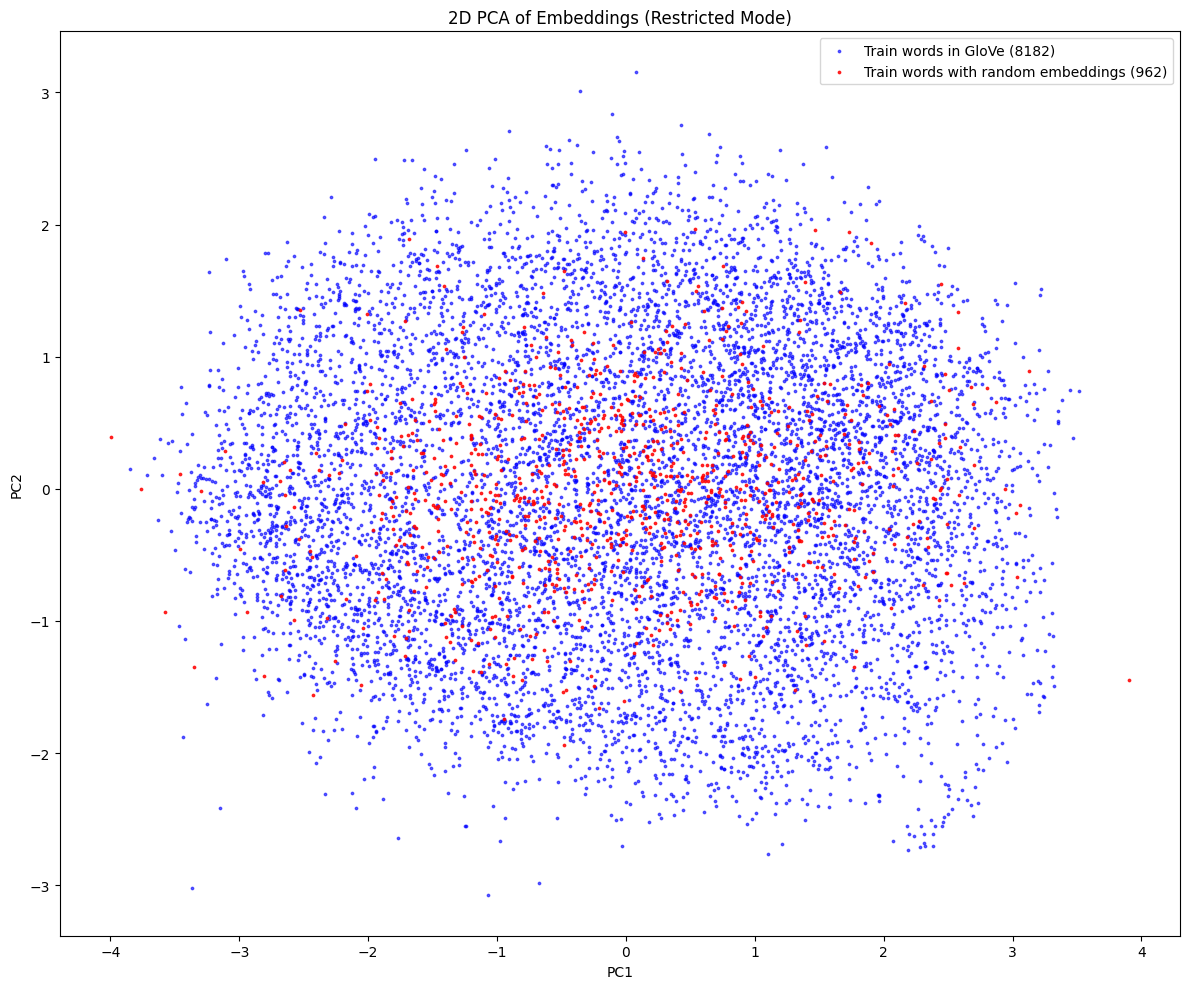

In [ ]:
embedding_vocab = set(embedding_model.index_to_key)
train_vocab = set(train_words)

if USE_FULL_PRELOAD_EMB_MODEL:
    # Full-preload mode: visualize all words in tokenizer with category distinctions
    
    # Get all words from tokenizer
    tokenizer_words = set(tokenizer.word_index.keys())
    
    # Categorize based on origin
    cat_train_in_embed = list(train_vocab & embedding_vocab)        # Train words with GloVe embeddings
    cat_embed_only = list((tokenizer_words & embedding_vocab) - train_vocab)  # GloVe words not in train
    cat_train_random = list(train_vocab - embedding_vocab)          # Train words with random embeddings
    
    # Collect embedding vectors for each category
    embed_train_in_embed = np.array([embedding_matrix[tokenizer.word_index[t]] for t in cat_train_in_embed])
    embed_embed_only = np.array([embedding_matrix[tokenizer.word_index[t]] for t in cat_embed_only])
    embed_train_random = np.array([embedding_matrix[tokenizer.word_index[t]] for t in cat_train_random])
    
    # Combine all vectors for PCA
    all_embeddings = np.concatenate([embed_train_in_embed, embed_embed_only, embed_train_random], axis=0)
    pca = PCA(n_components=2)
    all_2d = pca.fit_transform(all_embeddings)
    
    # Split projected coordinates by category
    n_train_in_embed = len(embed_train_in_embed)
    n_embed_only = len(embed_embed_only)
    n_train_random = len(embed_train_random)
    
    coords_train_in_embed = all_2d[:n_train_in_embed]
    coords_embed_only = all_2d[n_train_in_embed:n_train_in_embed + n_embed_only]
    coords_train_random = all_2d[n_train_in_embed + n_embed_only:]
    
    # Plot each category
    plt.figure(figsize=(12, 10))
    plt.scatter(coords_train_in_embed[:, 0], coords_train_in_embed[:, 1], s=3, alpha=0.6, color="blue",
                label=f"Train words in GloVe ({len(cat_train_in_embed)})")
    plt.scatter(coords_embed_only[:, 0], coords_embed_only[:, 1], s=3, alpha=0.4, color="green",
                label=f"GloVe words not in train ({len(cat_embed_only)})")
    plt.scatter(coords_train_random[:, 0], coords_train_random[:, 1], s=3, alpha=0.8, color="red",
                label=f"Train words with random embeddings ({len(cat_train_random)})")
    
    plt.title("2D PCA of Embeddings (Full Model Mode)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    # Restricted mode: only train words are in tokenizer
    
    # Get all words from tokenizer (should be only train_vocab)
    tokenizer_words = set(tokenizer.word_index.keys())
    
    # Categorize based on whether they have GloVe embeddings or random ones
    cat_train_in_embed = list(train_vocab & embedding_vocab)    # Train words with GloVe embeddings
    cat_train_random = list(train_vocab - embedding_vocab)      # Train words with random embeddings

    # Collect embedding vectors for each category
    embed_train_in_embed = np.array([embedding_matrix[tokenizer.word_index[t]] for t in cat_train_in_embed])
    embed_train_random = np.array([embedding_matrix[tokenizer.word_index[t]] for t in cat_train_random])

    # Combine all vectors for PCA
    all_embeddings = np.concatenate([embed_train_in_embed, embed_train_random], axis=0)
    pca = PCA(n_components=2)
    all_2d = pca.fit_transform(all_embeddings)

    # Split projected coordinates by category
    n_train_in_embed = len(embed_train_in_embed)
    n_train_random = len(embed_train_random)

    coords_train_in_embed = all_2d[:n_train_in_embed]
    coords_train_random = all_2d[n_train_in_embed:]

    # Plot each category
    plt.figure(figsize=(12, 10))
    plt.scatter(coords_train_in_embed[:, 0], coords_train_in_embed[:, 1], s=3, alpha=0.6, color="blue",
                label=f"Train words in GloVe ({len(cat_train_in_embed)})")
    plt.scatter(coords_train_random[:, 0], coords_train_random[:, 1], s=3, alpha=0.8, color="red",
                label=f"Train words with random embeddings ({len(cat_train_random)})")

    plt.title("2D PCA of Embeddings (Restricted Mode)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

# [Task 4 - 1.0 points] Model definition

You are now tasked to define your sexism classifier.




### Instructions

* **Baseline**: implement a Bidirectional LSTM with a Dense layer on top.

* **Stacked**: add an additional Bidirectional LSTM layer to the Baseline model.

**Note**: You are **free** to experiment with hyper-parameters.

In [ ]:
NUM_CLASSES = len(label_mapping.keys())
MAX_SEQ_LEN = max([df['cleaned_lemm_tweet'].apply(lambda x: len(x.split())).max() for df in dfs])

# NOTE: la struttura potrebbe essere too much ma visto che con ipcv ci eravamo trovati "bene" a testarla l'ho riproposta
hyperparams_models = {
    "baseline": {
        "model": {
            "lstm_units": 256,
            "dense_units": 32,
            "dropout_rate": 0.3,   
        },
        "train": {}
    },
    "stacked": {
        "model": {
            "lstm_units_1": 256,
            "lstm_units_2": 256,
            "dense_units": 32,
            "dropout_rate_1": 0.3,
            "dropout_rate_2": 0.3,
        },
        "train": {}
    }
}

### Token to embedding mapping

You can follow two approaches for encoding tokens in your classifier.

### Work directly with embeddings

- Compute the embedding of each input token
- Feed the mini-batches of shape ``(batch_size, # tokens, embedding_dim)`` to your model

### Work with Embedding layer

- Encode input tokens to token ids
- Define a Embedding layer as the first layer of your model
- Compute the embedding matrix of all known tokens (i.e., tokens in your vocabulary)
- Initialize the Embedding layer with the computed embedding matrix
- You are **free** to set the Embedding layer trainable or not

In [ ]:
models = {
    "baseline" : Sequential([
        Input(shape=(MAX_SEQ_LEN,)),
        Embedding(
            input_dim=vocab_size, 
            output_dim=EMBEDDING_DIMENSION,
            weights=[embedding_matrix],
            mask_zero=True,
            name='encoder_embedding'
        ),
        Bidirectional(LSTM(
            units=hyperparams_models["baseline"]["model"]["lstm_units"],
            return_sequences=False
        )),
        Dropout(hyperparams_models["baseline"]["model"]["dropout_rate"]),
        Dense(
            units=hyperparams_models["baseline"]["model"]["dense_units"],
            activation='relu'
        ),
        Dense(units=NUM_CLASSES, activation='softmax')
    ], name="baseline_bidirectional_lstm"),
    
    "stacked" : Sequential([
        Input(shape=(MAX_SEQ_LEN,)),
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIMENSION,
            weights=[embedding_matrix],
            mask_zero=True,
            name='encoder_embedding'
        ),
        Bidirectional(LSTM(
            units=hyperparams_models["stacked"]["model"]["lstm_units_1"],
            return_sequences=True  # NOTE: return sequences for stacking
        )),
        Dropout(hyperparams_models["stacked"]["model"]["dropout_rate_1"]),
        Bidirectional(LSTM(
            units=hyperparams_models["stacked"]["model"]["lstm_units_2"],
            return_sequences=False
        )),
        Dropout(hyperparams_models["stacked"]["model"]["dropout_rate_2"]),
        Dense(
            units=hyperparams_models["stacked"]["model"]["dense_units"],
            activation='relu'
        ),
        Dense(units=NUM_CLASSES, activation='softmax')
    ], name="stacked_bidirectional_lstm")
}

# [Task 5 - 1.0 points] Training and Evaluation

You are now tasked to train and evaluate the Baseline and Stacked models.



### Instructions

* Pick **at least** three seeds for robust estimation.
* Train **all** models on the train set.
* Evaluate **all** models on the validation and test sets.
* Compute macro F1-score, precision, and recall metrics on the validation set.
* Report average and standard deviation measures over seeds for each metric.
* Pick the **best** performing model according to the observed validation set performance (use macro F1-score).

# [Task 6 - 1.0 points] Transformers

In this section, you will use a transformer model specifically trained for hate speech detection, namely [Twitter-roBERTa-base for Hate Speech Detection](https://huggingface.co/cardiffnlp/twitter-roberta-base-hate).




### Relevant Material
- Tutorial 3

### Instructions
- **Load the Tokenizer and Model**

- **Preprocess the Dataset**:
   You will need to preprocess your dataset to prepare it for input into the model. Tokenize your text data using the appropriate tokenizer and ensure it is formatted correctly.

- **Train the Model**:
   Use the `Trainer` to train the model on your training data.

- **Evaluate the Model on the Test Set** using the same metrics used for LSTM-based models.

--- 

### Utilites

In [10]:
# Function to explore datasets
def print_datasets_info(train_data, test_data, val_data, tokenizer):
    print(60*"-")
    print("Datasets info:")
    print(60*"-")
    print(f"Train data dimension: {train_data.num_rows}")
    print(f"Test data dimension: {test_data.num_rows}")
    print(f"Validation data dimension: {val_data.num_rows}")
    print(60*"-")
    print(f"columns of datasets objects: {train_data.features}")
    print(60*"-")
    print("Encoding of labels:")
    print(" \"-\":0, \"DIRECT\":1, \"JUDGEMENTAL\":2, \"REPORTED\":3")
    print(set(train_data['label']))

    original_text = train_data['tweet'][26:30]
    decoded_text = tokenizer.batch_decode(train_data['input_ids'][26:30])
    id_text = train_data['input_ids'][26:30]
    print(60*"-")
    for i in range(len(original_text)):
        print(f"Original tweet: {original_text[i][:150]}")
        print(f"Token IDs: {id_text[i][:150]}")
        print(f"Decoded tweet: {decoded_text[i][:150]}")
        print(30*"-")

# Metrics computation
def compute_metrics(output_info):
    logits, labels = output_info
    preds = np.argmax(logits, axis=-1)
    f1 = f1_score(labels, preds, average="macro")
    accuracy = accuracy_score(labels, preds)

    return {
        "macro_f1": f1,
        "macro_precision": precision_score(labels, preds, average="macro", zero_division=0),
        "macro_recall": recall_score(labels, preds, average="macro", zero_division=0),
        "accuracy": accuracy
    }

# Function to count trainable parameters when fine-tuning partially
def count_trainable_parameters(m):
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total = sum(p.numel() for p in m.parameters())
    return trainable, total

# Training and evaluation function
def train_evaluate_model(
    seeds: list[int],
    hyperparameters: dict,
    output_dir: str = "./pt_checkpoints",
    fine_tune_partially: bool = False,
    early_patience: int = 0,
    VERBOSE: bool = True,
    best_subdir_name: str = "best_model"  # folder name inside each run folder where best model is saved
) -> tuple[list[dict], dict, dict]:
    """
    Returns:
      - results: list[dict] with per-seed metrics (same as before)
      - logs: dict of raw trainer.log_history if DEBUG True per seed
      - best_model_dirs: dict mapping seed -> path where the seed's best model is saved
    """
    results = []
    logs = {}
    best_model_dirs = {}

    for seed in seeds:
        # deterministic seeds 
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        # HF helper (sets python/numpy/torch seeds)
        set_seed(seed)

        # HF helper (sets python/numpy/torch seeds)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        # unique output folder per seed so things don't overwrite
        run_output_dir = os.path.join(output_dir, f"seed_{seed}")
        os.makedirs(run_output_dir, exist_ok=True)
        
        hf_logging.set_verbosity_error()
        # Model loading
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_CARD,
            num_labels=NUM_LABLES,
            from_tf=False,
            ignore_mismatched_sizes=True,
            id2label=reverse_mapping,
            label2id=label_mapping
        )
        hf_logging.set_verbosity_warning() 

        if VERBOSE:
            if seed == seeds[0]:
                print("=== Model Summary ===")
                print(model)
                trainable, total = count_trainable_parameters(model)
                print("=== Trainable Parameters ===")
                print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

        print(f"\n=== RUN seed={seed} ===")

        if fine_tune_partially:
            for param in model.roberta.parameters():
                param.requires_grad = False
            for name, param in model.named_parameters():
                if "classifier" in name or "pooler" in name or "dense" in name:
                    param.requires_grad = True
            trainable, total = count_trainable_parameters(model)
            if seed == seeds[0]:
                print("Freezing encoder parameters, fine-tuning classification head only.")
                print(f"Trainable params after freezing encoder: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

        # Training
        training_args = TrainingArguments(
            output_dir=run_output_dir,             
            learning_rate=hyperparameters["learning_rate"],                   
            per_device_train_batch_size=hyperparameters["batch_size"],     # defines distributed training
            per_device_eval_batch_size=hyperparameters["batch_size"],
            num_train_epochs=hyperparameters["epochs"],
            weight_decay=hyperparameters["weight_decay"],
            eval_strategy="epoch",             # when to report evaluation metrics/losses
            save_strategy="epoch",             # when to save checkpoint
            logging_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="macro_f1",   # ensure best model by macro F1
            greater_is_better=True,
            report_to='none',                   # disabling wandb 
            seed=seed
        )
        if early_patience > 0:
            trainer = Trainer(
                model=model,
                args=training_args,
                train_dataset=TRAIN_DATA,
                eval_dataset=VAL_DATA,
                processing_class=tokenizer,
                data_collator=data_collator,
                compute_metrics=compute_metrics,
                callbacks=[EarlyStoppingCallback(early_stopping_patience=early_patience)]
            )
        else:
            trainer = Trainer(
                model=model,
                args=training_args,
                train_dataset=TRAIN_DATA,
                eval_dataset=VAL_DATA,
                processing_class=tokenizer,
                data_collator=data_collator,
                compute_metrics=compute_metrics
            )

        trainer.train()

        # gather logs 
        logs_hist = trainer.state.log_history
        df_logs = pd.DataFrame(logs_hist)
        logs[seed] = df_logs

        # best info
        best_metric = trainer.state.best_metric
        # epoch number from folder name
        best_epoch = int(trainer.state.best_model_checkpoint.split("-")[-1]) / 360

        # Evaluate on validation and test
        val_res = trainer.evaluate(eval_dataset=VAL_DATA)
        test_res = trainer.evaluate(eval_dataset=TEST_DATA)

        record = {
            "seed": seed,
            "val_macro_f1": val_res.get("eval_macro_f1"),
            "val_macro_precision": val_res.get("eval_macro_precision"),
            "val_macro_recall": val_res.get("eval_macro_recall"),
            "val_accuracy": val_res.get("eval_accuracy"),
            "test_macro_f1": test_res.get("eval_macro_f1"),
            "test_macro_precision": test_res.get("eval_macro_precision"),
            "test_macro_recall": test_res.get("eval_macro_recall"),
            "test_accuracy": test_res.get("eval_accuracy"),
            "best_epoch": best_epoch,
            "best_metric": best_metric,
        }
        results.append(record)
        
        if best_subdir_name is not None:
            # Save best model into a dedicated subfolder so it's easy to reload later
            best_dir = os.path.join(run_output_dir, best_subdir_name)
            os.makedirs(best_dir, exist_ok=True)

            # Trainer.save_model will save the model and config into best_dir
            trainer.save_model(best_dir)

            best_model_dirs[seed] = best_dir

        # clean up GPU memory
        del trainer
        del model
        torch.cuda.empty_cache()
        gc.collect()

    return results, logs, best_model_dirs

# Compute mean and std (for validation and test metrics)
def mean_std(df_out: pd.DataFrame):
    metrics_to_agg = [
        "val_macro_f1", "val_macro_precision", "val_macro_recall", "val_accuracy",
        "test_macro_f1", "test_macro_precision", "test_macro_recall", "test_accuracy"
    ]
    agg = df_out[metrics_to_agg].agg(["mean", "std"])

    # Select best run according to validation macro-F1
    best_idx = df_out["val_macro_f1"].idxmax()
    best_run = df_out.loc[best_idx]
    return agg, best_run


# Helper function to extract per-epoch metrics from log history DataFrame
def _epoch_aggregates(df: pd.DataFrame):
    """Return dicts of per-epoch Series for eval and train metrics (robust to missing columns)."""
    logs = df.copy()
    # eval rows: rows that contain eval_loss (evaluation events)
    if "eval_loss" in logs.columns:
        df_eval = logs[logs["eval_loss"].notna()].sort_values("step")
        if not df_eval.empty and "epoch" in df_eval.columns:
            df_eval = df_eval.groupby("epoch", as_index=False).last().sort_values("epoch")
        else:
            df_eval = pd.DataFrame()
    else:
        df_eval = pd.DataFrame()

    # train-step losses: rows where 'loss' (per-step) is logged
    if "loss" in logs.columns:
        df_train_steps = logs[logs["loss"].notna()].sort_values("step")
        if "epoch" in df_train_steps.columns:
            df_train_steps = df_train_steps.groupby("epoch", as_index=False).last().sort_values("epoch")
        # if epoch missing we still keep the sequence by step
    else:
        df_train_steps = pd.DataFrame()

    # Build per-epoch arrays (index = epoch)
    def series_from_eval(col):
        return df_eval.set_index("epoch")[col] if (not df_eval.empty and col in df_eval.columns) else pd.Series(dtype=float)

    eval_f1 = series_from_eval("eval_macro_f1")
    eval_prec = series_from_eval("eval_macro_precision")
    eval_rec = series_from_eval("eval_macro_recall")
    eval_loss = series_from_eval("eval_loss")
    eval_acc = series_from_eval("eval_accuracy")

    # Derive train_loss_per_epoch: prefer df_train_steps grouped by epoch if available,
    # otherwise attempt to map last step before each eval step.
    train_loss = pd.Series(dtype=float)
    if (not df_train_steps.empty) and ("epoch" in df_train_steps.columns):
        train_loss = df_train_steps.set_index("epoch")["loss"]
    elif (not df_train_steps.empty) and ("step" in df_train_steps.columns) and (not df_eval.empty):
        # fallback: find last train step <= eval step for each eval epoch
        tsteps = df_train_steps.set_index("step")["loss"]
        vals = {}
        for _, r in df_eval.iterrows():
            eval_step = int(r["step"]) if not pd.isna(r["step"]) else None
            epoch = r["epoch"] if "epoch" in r.index else None
            if eval_step is not None:
                keys = [s for s in tsteps.index if s <= eval_step]
                if keys:
                    vals[epoch] = float(tsteps.loc[keys[-1]])
                else:
                    vals[epoch] = np.nan
        if vals:
            train_loss = pd.Series(vals).sort_index()

    # optional train metrics if present
    train_f1 = df_train_steps.set_index("epoch")["train_macro_f1"] if ("train_macro_f1" in df_train_steps.columns and not df_train_steps.empty) else pd.Series(dtype=float)
    train_acc = df_train_steps.set_index("epoch")["train_accuracy"] if ("train_accuracy" in df_train_steps.columns and not df_train_steps.empty) else pd.Series(dtype=float)

    return {
        "epoch_index": eval_loss.index.tolist() if not eval_loss.empty else (train_loss.index.tolist() if not train_loss.empty else []),
        "eval_f1": eval_f1,
        "eval_prec": eval_prec,
        "eval_rec": eval_rec,
        "eval_loss": eval_loss,
        "eval_acc": eval_acc,
        "train_loss": train_loss,
        "train_f1": train_f1,
        "train_acc": train_acc
    }

# Plotting function for per-seed metrics
def plot_metrics_by_seed(logs_by_seed: Dict[int, pd.DataFrame], figsize_per_row=(10, 2.6)):
    """
    logs_by_seed: dict mapping seed -> trainer.state.log_history DataFrame
    Produces one figure: rows = seeds (sorted), columns = 2 plots per row:
      [ Precision/Recall/F1 ] [ Loss (train/val) vs Accuracy (val/train optional) ]
    """
    if not logs_by_seed:
        raise ValueError("Empty logs_by_seed")

    seeds = sorted(logs_by_seed.keys())
    n = len(seeds)
    fig_height = figsize_per_row[1] * n
    fig_width = figsize_per_row[0]
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(fig_width, fig_height), squeeze=False)

    for i, seed in enumerate(seeds):
        df_logs = logs_by_seed[seed]
        agg = _epoch_aggregates(df_logs)

        epochs = agg["epoch_index"]

        # Left: Precision / Recall / F1 (eval) and optional train dashed lines
        ax = axes[i, 0]
        plotted = False
        if len(agg["eval_prec"]) > 0:
            ax.plot(agg["eval_prec"].index, agg["eval_prec"].values, marker="o", label="val Precision")
            plotted = True
        if len(agg["eval_rec"]) > 0:
            ax.plot(agg["eval_rec"].index, agg["eval_rec"].values, marker="o", label="val Recall")
            plotted = True
        if len(agg["eval_f1"]) > 0:
            ax.plot(agg["eval_f1"].index, agg["eval_f1"].values, marker="o", label="val F1")
            plotted = True
        # overlay train metrics (dashed)
        if len(agg["train_f1"]) > 0:
            ax.plot(agg["train_f1"].index, agg["train_f1"].values, linestyle="--", marker="x", label="train F1")
        # Labels and formatting
        ax.set_ylim(-0.02, 1.02)
        ax.set_xlim(min(epochs) - 0.2 if epochs else 0, max(epochs) + 0.2 if epochs else 1)
        ax.set_title(f"seed={seed}  —  Precision / Recall / F1")
        ax.set_xlabel("epoch")
        ax.set_ylabel("score")
        ax.grid(alpha=0.3)
        if plotted:
            ax.legend(loc="lower right", fontsize="small")
        else:
            ax.text(0.5, 0.5, "no eval prec/rec/f1", ha="center", va="center")

        # Right: Loss vs Accuracy (train & val)
        ax2 = axes[i, 1]
        any_plot = False
        # train loss
        if len(agg["train_loss"]) > 0:
            ax2.plot(agg["train_loss"].index, agg["train_loss"].values, linestyle="--", marker=".", label="train loss", color="C1")
            any_plot = True
        # eval loss
        if len(agg["eval_loss"]) > 0:
            ax2.plot(agg["eval_loss"].index, agg["eval_loss"].values, linestyle="--", marker=".", label="val loss", color="C3")
            any_plot = True

        # accuracy on twin axis
        if len(agg["eval_acc"]) > 0 or len(agg["train_acc"]) > 0:
            ax2_t = ax2.twinx()
            if len(agg["eval_acc"]) > 0:
                ax2_t.plot(agg["eval_acc"].index, agg["eval_acc"].values, linestyle="-.", marker="v", label="val acc", color="C2")
                any_plot = True
            if len(agg["train_acc"]) > 0:
                ax2_t.plot(agg["train_acc"].index, agg["train_acc"].values, linestyle="-.", marker="v", label="train acc", color="C4")
                any_plot = True
            ax2_t.set_ylim(-0.02, 1.02)
            ax2_t.set_ylabel("accuracy", color="C2")
        # formatting
        ax2.set_xlabel("epoch")
        ax2.set_ylabel("loss")
        ax2.grid(alpha=0.3)
        ax2.set_title(f"seed={seed}  —  Loss vs Accuracy")
        if any_plot:
            # combine legends from ax2 and twin axis if present
            handles, labels = ax2.get_legend_handles_labels()
            if 'ax2_t' in locals():
                h2, l2 = ax2_t.get_legend_handles_labels()
                handles += h2; labels += l2
            ax2.legend(handles, labels, loc="lower left", fontsize="small")
        else:
            ax2.text(0.5, 0.5, "no loss/accuracy logs", ha="center", va="center")

    plt.tight_layout()
    plt.show()

# Summary metrics plotting function
def plot_summary_metrics(df_out: pd.DataFrame, agg: pd.DataFrame, best_run: pd.Series = None,
                         figsize=(12, 10), save_path: str = None):
    """
    3-row figure:
      row1: grouped bars for validation metrics (one bar per seed per metric)
      row2: grouped bars for test metrics
      row3: mean ± std for each metric across seeds (no boxplots)
    """
    val_metrics = ["val_macro_f1", "val_macro_precision", "val_macro_recall", "val_accuracy"]
    test_metrics = ["test_macro_f1", "test_macro_precision", "test_macro_recall", "test_accuracy"]
    all_metrics = val_metrics + test_metrics

    # Input checks
    missing = [c for c in all_metrics if c not in df_out.columns]
    if missing:
        raise ValueError(f"df_out missing columns: {missing}")

    seeds = df_out["seed"].tolist()
    n_seeds = len(seeds)
    cmap = plt.get_cmap("tab10")

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=figsize)
    plt.subplots_adjust(hspace=0.5)

    # Row 1: Validation grouped bars
    ax = axes[0]
    x = np.arange(len(val_metrics))
    total_width = 0.8
    bar_width = total_width / max(1, n_seeds)
    offsets = np.linspace(-total_width/2 + bar_width/2, total_width/2 - bar_width/2, n_seeds)

    for i, (seed, offset) in enumerate(zip(seeds, offsets)):
        row = df_out[df_out["seed"] == seed].iloc[0]
        vals = [row[m] for m in val_metrics]
        edge = 'black' if (best_run is not None and seed == int(best_run["seed"])) else None
        lw = 1.6 if (best_run is not None and seed == int(best_run["seed"])) else 0.6
        ax.bar(x + offset, vals, width=bar_width, alpha=0.85, label=f"seed {seed}", color=cmap(i % 10),
               edgecolor=edge, linewidth=lw)

    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("val_", "") for m in val_metrics], rotation=0)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("score")
    ax.set_title("Validation metrics by seed")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(ncol=min(4, n_seeds), fontsize="small", loc="upper center", bbox_to_anchor=(0.5, -0.15))

    # Row 2: Test grouped bars
    ax = axes[1]
    x = np.arange(len(test_metrics))
    for i, (seed, offset) in enumerate(zip(seeds, offsets)):
        row = df_out[df_out["seed"] == seed].iloc[0]
        vals = [row[m] for m in test_metrics]
        edge = 'black' if (best_run is not None and seed == int(best_run["seed"])) else None
        lw = 1.6 if (best_run is not None and seed == int(best_run["seed"])) else 0.6
        ax.bar(x + offset, vals, width=bar_width, alpha=0.85, label=f"seed {seed}", color=cmap(i % 10),
               edgecolor=edge, linewidth=lw)

    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("test_", "") for m in test_metrics], rotation=0)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("score")
    ax.set_title("Test metrics by seed")
    ax.grid(axis="y", alpha=0.3)

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    # Row 3: Mean ± Std only (no boxplots)
    ax = axes[2]
    # get means and stds from agg if available; otherwise compute from df_out
    if ("mean" in agg.index) and ("std" in agg.index):
        means = agg.loc["mean", all_metrics].values
        stds = agg.loc["std", all_metrics].values
    else:
        means = np.array([df_out[m].mean() for m in all_metrics])
        stds = np.array([df_out[m].std(ddof=1) for m in all_metrics])

    x = np.arange(len(all_metrics))
    colors = [cmap(i % 10) for i in range(len(all_metrics))]
    bars = ax.bar(x, means, yerr=stds, capsize=6, tick_label=[m for m in all_metrics],
                  color=colors, alpha=0.85, edgecolor='k')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("mean ± std")
    ax.set_title("Mean ± Std across seeds (validation + test metrics)")
    ax.grid(axis="y", alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    # optional: annotate mean values above bars
    for xi, (mu, sigma) in enumerate(zip(means, stds)):
        ax.text(xi, mu + sigma + 0.02, f"{mu:.3f}±{sigma:.3f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

# Confusion matrix computation
def get_confusion_matrix_with_trainer(model_path, dataset, label_names):
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    
    training_args = TrainingArguments(report_to='none')
    trainer = Trainer(
        model=model,
        args=training_args,
        processing_class=tokenizer,
        data_collator=data_collator
    )
    
    predictions = trainer.predict(dataset)
    y_pred = np.argmax(predictions.predictions, axis=-1)
    y_true = predictions.label_ids
    
    return confusion_matrix(y_true, y_pred), y_true, y_pred

# Plot confusion matrices
def plot_confusion_matrices(best_model_dirs, best_seed, label_names):
    val_cm, val_true, val_pred = get_confusion_matrix_with_trainer(
        best_model_dirs[best_seed], VAL_DATA, label_names
    )
    test_cm, test_true, test_pred = get_confusion_matrix_with_trainer(
        best_model_dirs[best_seed], TEST_DATA, label_names
    )

    # Plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_names, yticklabels=label_names, ax=axes[0])
    axes[0].set_title('Validation Confusion Matrix')
    sns.heatmap(test_cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=label_names, yticklabels=label_names, ax=axes[1])
    axes[1].set_title('Test Confusion Matrix')
    plt.tight_layout()
    plt.show()

# Main function to print outputs and plot histograms
def print_outputs_and_hystograms(df_out, name_model):
    agg, best_run = mean_std(df_out)
    best_seed = int(best_run.to_dict()["seed"])
    print(f"---   Results for {name_model} Fine-Tuning of the 3 seeds   ---")
    print("Best model, according to F1, is the one with the seed =", best_seed)
    print(58*"-")
    print("---  validation  ---")
    display(df_out.filter(regex='seed|best_epoch|val').sort_values("val_macro_f1", ascending=False))
    print("---     test     ---")
    display(df_out.sort_values("val_macro_f1", ascending=False).filter(regex='seed|best_epoch|test'))
    print("Mean and Std for Partial Fine-Tuning:")
    display(agg)
    plot_summary_metrics(df_out, agg, best_run)
    return agg, best_run, best_seed


--- 

As first step, we load the tokenizer and the collator, used for adding padding during batching. We also prepare the datasets, taking the tweets resulting from task 1 (so not lemmatized/cleaned)

In [11]:
TASK='hate'
MODEL_CARD = f"twitter-roberta-base-{TASK}"
NUM_LABLES = 4
output_dir = "./pt_checkpoints_5"
seeds = [90, 26, 6]

# Dataset preparation

# TODO: tokenizer = AutoTokenizer.from_pretrained(MODEL_CARD)
tokenizer = AutoTokenizer.from_pretrained(MODEL_CARD, use_fast=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def preprocess_text_vanilla(tweets):
    return tokenizer(tweets['tweet'])

TRAIN_DATA = Dataset.from_pandas(train_df[["tweet","label"]])
TEST_DATA = Dataset.from_pandas(test_df[["tweet","label"]])
VAL_DATA = Dataset.from_pandas(val_df[["tweet","label"]])
TRAIN_DATA = TRAIN_DATA.map(preprocess_text_vanilla, batched=True)
TEST_DATA = TEST_DATA.map(preprocess_text_vanilla, batched=True)
VAL_DATA = VAL_DATA.map(preprocess_text_vanilla, batched=True)

Map:   0%|          | 0/2873 [00:00<?, ? examples/s]

Map:   0%|          | 0/280 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

In [12]:
# We check brefly the structure and sanity of datasets and the decoding of the labels.
print_datasets_info(TRAIN_DATA, TEST_DATA, VAL_DATA, tokenizer)

------------------------------------------------------------
Datasets info:
------------------------------------------------------------
Train data dimension: 2873
Test data dimension: 280
Validation data dimension: 150
------------------------------------------------------------
columns of datasets objects: {'tweet': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}
------------------------------------------------------------
Encoding of labels:
 "-":0, "DIRECT":1, "JUDGEMENTAL":2, "REPORTED":3
{0, 1, 2, 3}
------------------------------------------------------------
Original tweet: Anita as an asset? Damn I should've considered that. Her vs gamergate was one big spectacle https://t.co/x2k5KDnUt2
Token IDs: [0, 4688, 3119, 25, 41, 3440, 116, 41163, 38, 197, 348, 1687, 14, 4, 1405, 1954, 36761, 7357, 21, 65, 380, 20286, 1205, 640, 90, 4, 876, 73, 1178, 176, 330, 245, 530, 495, 282, 41967, 176, 2]
Decoded tweet: <s>Anita 

As said before, we can see that the dataset is pretty small and the most data are used for $training\approx 87\%$ ($test\approx 8.5\%$ $validation\approx 87\%$).  
We can also notice that the they always start with 0 (\<s\> start of sentence) and end with 2 (\<s\> end of sentence).  
  
As second step we choose the hyperparams and train and evaluate on the validation set.  
After conducting several experiments, we decided on these hyperparameters. Notably, a batch size of 8 yielded the best validation performance. This is plausibly due to higher gradient variance at smaller batch sizes, which can act as a regularizer and improve generalization given the limited dataset size.  
We also carried out several experiments to identify a learning rate that would avoid both early overfitting and underfitting. The choice of the learning rate proved to be crucial not only for training stability, but also for defining the strategy used to select the best epoch.  
During training, we observed a correlated behavior between validation loss and macro F1: while the validation loss often remained relatively stable or slightly increased, the macro F1 continued to improve. Given the strong class imbalance in the dataset, this allowed us to select the best model primarily based on macro F1.  
For this reason, we did not favor models that showed no signs of fitting the data at all, since in those cases the validation loss stayed flat but macro F1 remained lower. Instead, we preferred models with a slightly higher validation loss when this was accompanied by a meaningful improvement in macro F1, as this led to better performance on minority classes compared to models that strictly minimized validation loss but achieved worse overall classification balance.

In [13]:
# Hyperparameters
hyper = {
    "batch_size": 8,
    "epochs": 5,
    "learning_rate": 5e-6,
    "weight_decay": 0.01
}

### All Fine-tuning

In [14]:
results, logs, best_model_dirs = train_evaluate_model(
    seeds=seeds,
    hyperparameters=hyper,
    output_dir=output_dir,
    fine_tune_partially=False,
    early_patience=2,
    VERBOSE=True,
    best_subdir_name="best_model"
)
df_out = pd.DataFrame(results)
df_out = df_out.sort_values("val_macro_f1", ascending=False).reset_index(drop=True)

=== Model Summary ===
RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768

Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy
1,0.746100,0.653988,0.369715,0.348214,0.395031,0.773333
2,0.589900,0.603800,0.432401,0.607097,0.465450,0.800000
3,0.515800,0.594152,0.487592,0.519565,0.498628,0.813333
4,0.457900,0.631120,0.494788,0.555236,0.507117,0.813333
5,0.420500,0.617848,0.481455,0.494298,0.496247,0.806667



=== RUN seed=26 ===


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy
1,0.743300,0.669581,0.361183,0.344993,0.381781,0.760000
2,0.587100,0.597812,0.448489,0.598015,0.453675,0.786667
3,0.500000,0.661820,0.459486,0.467186,0.466020,0.793333
4,0.443800,0.666101,0.463083,0.467391,0.474508,0.793333
5,0.413400,0.658100,0.487273,0.490539,0.495342,0.800000



=== RUN seed=6 ===


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy
1,0.754400,0.650652,0.381877,0.345715,0.431366,0.780000
2,0.593100,0.634257,0.413728,0.592214,0.438949,0.773333
3,0.510700,0.637179,0.443939,0.512523,0.459783,0.780000
4,0.456400,0.661376,0.444907,0.477314,0.462164,0.786667
5,0.410600,0.654462,0.480910,0.481958,0.492961,0.793333


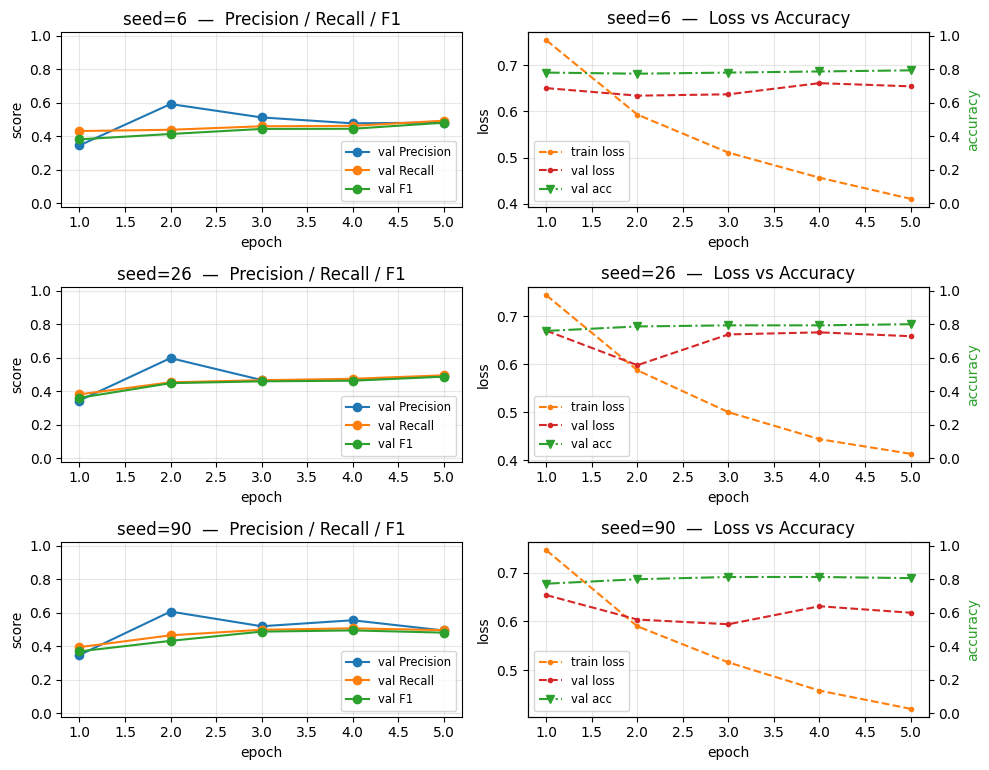

In [15]:
plot_metrics_by_seed(logs)

---   Results for Full Fine-Tuning of the 3 seeds   ---
Best model, according to F1, is the one with the seed = 90
----------------------------------------------------------
---  validation  ---


,seed,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,best_epoch
0,90,0.494788,0.555236,0.507117,0.813333,4.0
1,26,0.487273,0.490539,0.495342,0.800000,5.0
2,6,0.480910,0.481958,0.492961,0.793333,5.0


---     test     ---


,seed,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,best_epoch
0,90,0.446074,0.440097,0.459010,0.742857,4.0
1,26,0.463535,0.447227,0.481581,0.753571,5.0
2,6,0.457206,0.439088,0.478787,0.746429,5.0


Mean and Std for Partial Fine-Tuning:


,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy
mean,0.487657,0.509244,0.498473,0.802222,0.455605,0.442137,0.473126,0.747619
std,0.006947,0.040060,0.007580,0.010184,0.008840,0.004436,0.012304,0.005455


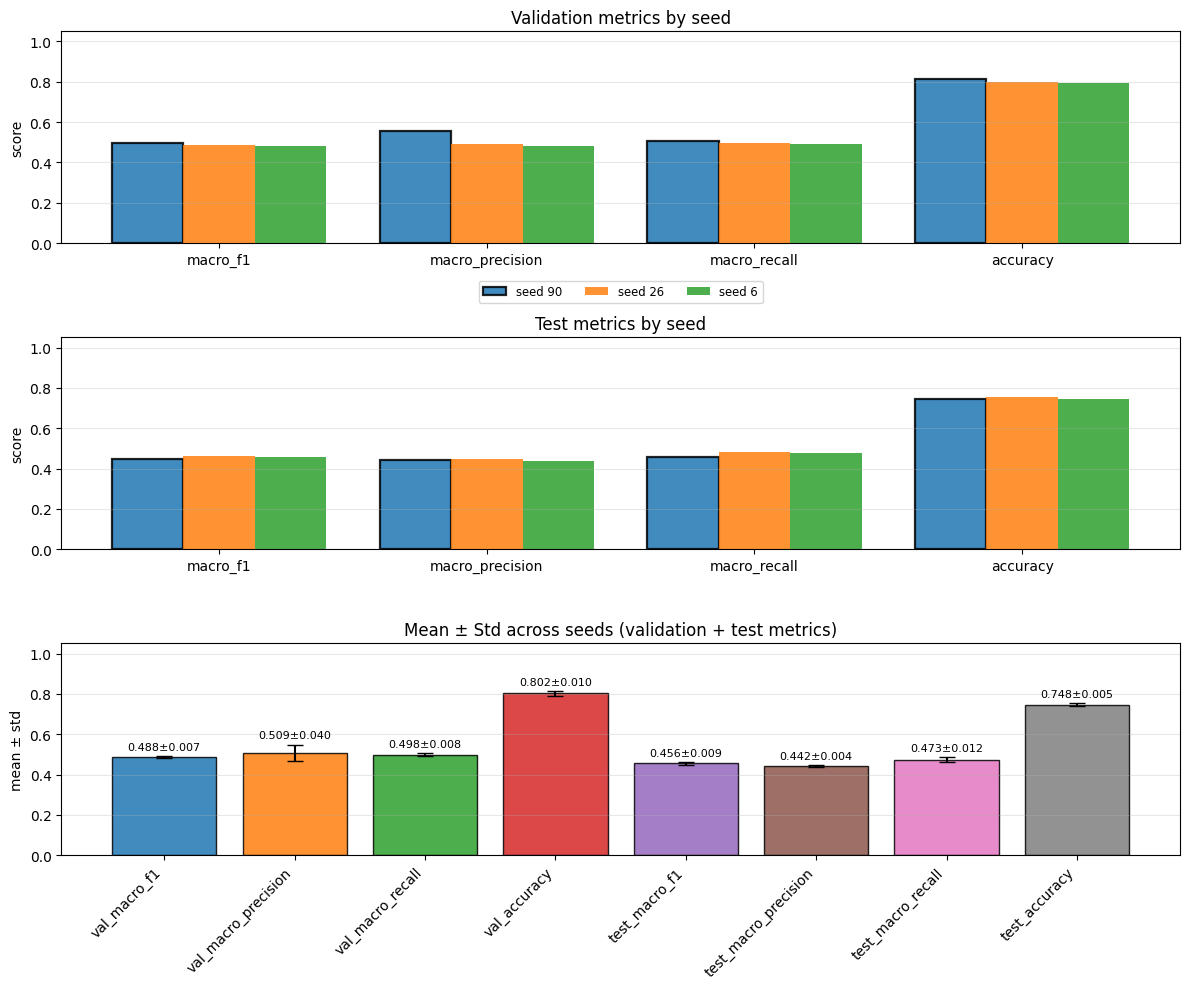

In [16]:
agg, best_run, best_seed = print_outputs_and_hystograms(df_out, name_model="Full")

From the outputs of the two previous cells, the previously discussed behavior can be observed. In particular, models 6 and 26, selected based on macro F1, are also those with the lowest validation loss. However, despite this, they perform worse than model 90, which shows clearer signs of overfitting but achieves higher macro F1 on both the validation and test sets.  
This highlights that minimizing validation loss does not necessarily lead to better performance in terms of macro F1, especially in the presence of class imbalance.  
To address this issue without complicating the model selection procedure and to reduce overfitting, we experimented with partial fine-tuning. In this setup, the encoder is frozen and only the pooler and classification (dense) layers are trained, limiting the number of trainable parameters and improving generalization. 

### Partial Fine-tuning

In [17]:
results_partial, logs_partial, best_model_dirs_partial = train_evaluate_model(
    seeds=seeds,
    hyperparameters=hyper,
    output_dir=output_dir,
    fine_tune_partially=True,
    early_patience=2,
    VERBOSE=False,
    best_subdir_name="best_model_partial"
)
df_out_partial = pd.DataFrame(results_partial)
df_out_partial = df_out_partial.sort_values("val_macro_f1", ascending=False).reset_index(drop=True)


=== RUN seed=90 ===
Freezing encoder parameters, fine-tuning classification head only.
Trainable params after freezing encoder: 64,349,956 / 124,648,708 (51.63%)


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy
1,0.755100,0.660003,0.365399,0.342000,0.392650,0.766667
2,0.604200,0.623689,0.385940,0.350039,0.433747,0.786667
3,0.543900,0.603885,0.427323,0.604300,0.454581,0.793333
4,0.495000,0.621440,0.495670,0.611045,0.504736,0.806667
5,0.465400,0.613837,0.487689,0.550053,0.496247,0.806667



=== RUN seed=26 ===


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy
1,0.750200,0.679140,0.369846,0.350993,0.392650,0.766667
2,0.598600,0.613427,0.440710,0.592262,0.442805,0.780000


KeyboardInterrupt: 

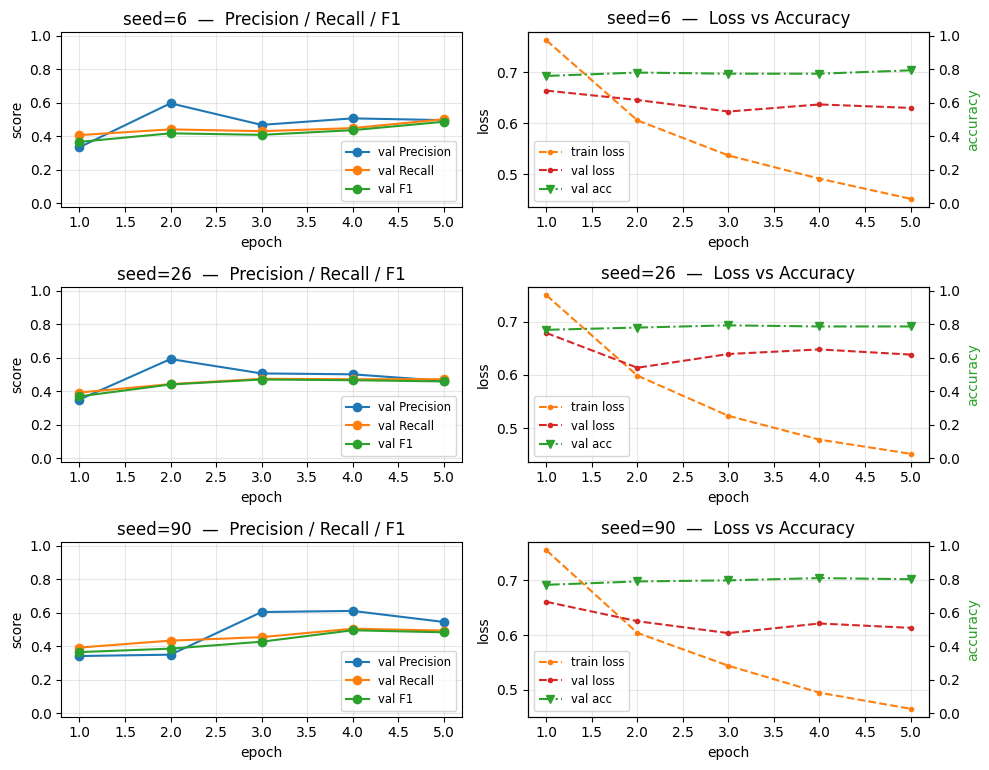

In [ ]:
plot_metrics_by_seed(logs_partial)

---   Results for Partial Fine-Tuning of the 3 seeds   ---
Best model, according to F1, is the one with the seed = 90
----------------------------------------------------------
---  validation  ---


,seed,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,best_epoch
0,90,0.495670,0.611045,0.504736,0.806667,4.0
1,6,0.486660,0.496390,0.501449,0.793333,5.0
2,26,0.470323,0.506532,0.474508,0.793333,3.0


---     test     ---


,seed,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,best_epoch
0,90,0.430253,0.432900,0.446058,0.750000,4.0
1,6,0.458650,0.442299,0.476344,0.753571,5.0
2,26,0.448327,0.458040,0.454246,0.764286,3.0


Mean and Std for Partial Fine-Tuning:


,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy
mean,0.484218,0.537989,0.493565,0.797778,0.445743,0.444413,0.458883,0.755952
std,0.012849,0.063471,0.016585,0.007698,0.014374,0.012703,0.015666,0.007435


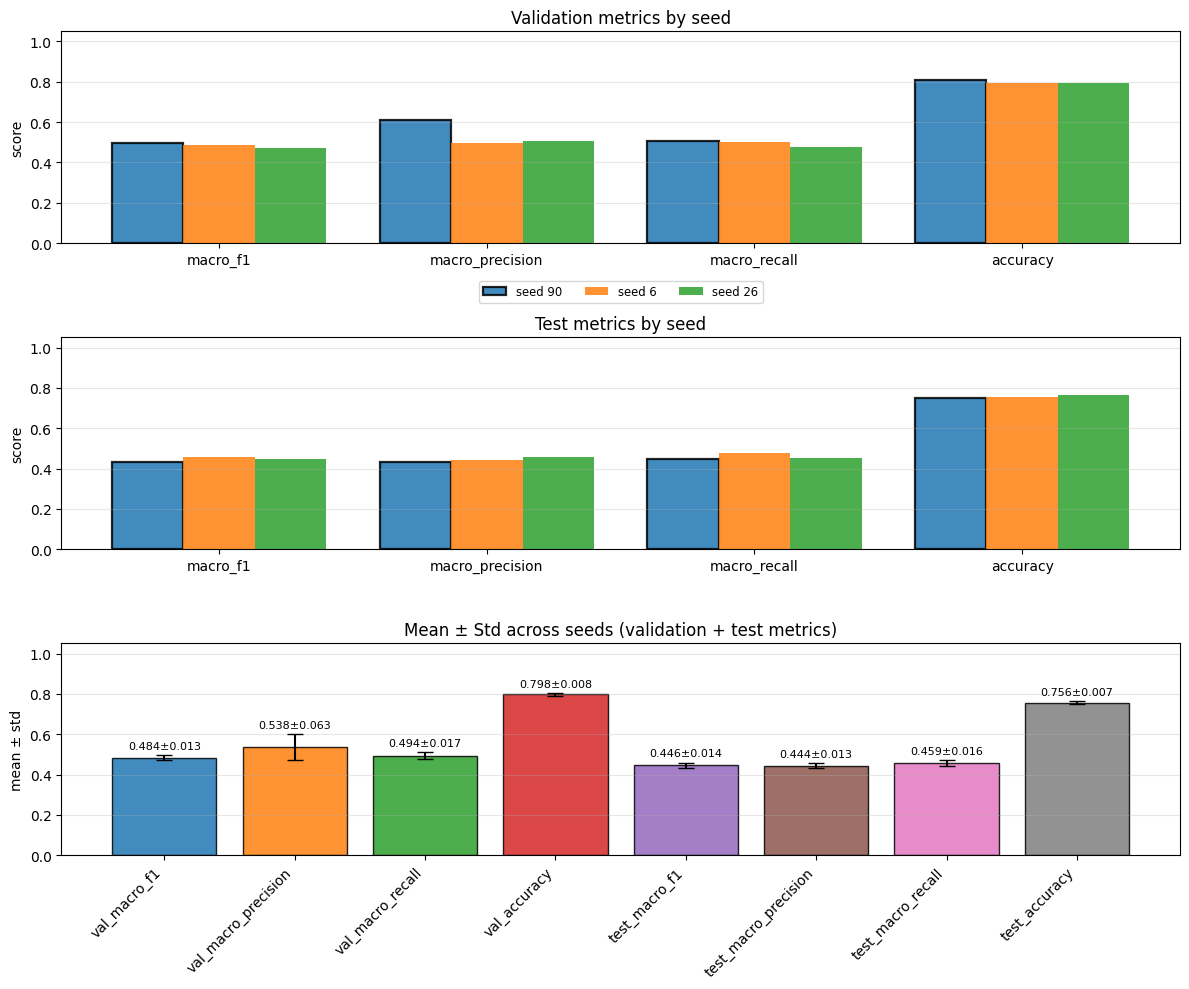

In [ ]:
agg_partial, best_run_partial, best_seed_partial = print_outputs_and_hystograms(df_out_partial, name_model="Partial")

---

### Reloading weights of the best model

The best model is the partially fine tuned with seed = 90, with test_macro_f1 = 0.515616  

In [ ]:
# Reload and saved best model for seed best_seed and evaluate on test set:
best_dir_for_seed = best_model_dirs_partial[best_seed_partial]
# Load best model
model_seed = AutoModelForSequenceClassification.from_pretrained(best_dir_for_seed)
tokenizer = AutoTokenizer.from_pretrained(best_dir_for_seed)
# Move model to device
model_seed.to('cuda' if torch.cuda.is_available() else 'cpu')
# Evaluate on test set
training_args = TrainingArguments(report_to='none')
trainer = Trainer(
    model=model_seed,
    args=training_args,
    eval_dataset=TEST_DATA,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
metrics = trainer.evaluate()
print(58*"-")
print("Best model, according to F1, is the one with the seed =", best_seed)
print(58*"-")
df_temp = pd.DataFrame([metrics]).rename(columns=lambda x: x.replace('eval_', 'test_'))
display(df_temp)

----------------------------------------------------------
Best model, according to F1, is the one with the seed = 90
----------------------------------------------------------


,test_loss,test_model_preparation_time,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,test_runtime,test_samples_per_second,test_steps_per_second
0,0.734546,0.0016,0.430253,0.4329,0.446058,0.75,0.6806,411.431,51.429


# [Task 7 - 0.5 points] Error Analysis

After evaluating the model, perform a brief error analysis on the **test set**:

### Instructions

 - Review the results and identify common errors.

 - Summarize your findings regarding the errors and their impact on performance (e.g. but not limited to Out-of-Vocabulary (OOV) words, data imbalance, and performance differences between the custom model and the transformer...)
 - Suggest possible solutions to address the identified errors.

### Additional tests about ROBERTA model

In [ ]:
def preprocess_text_precleaned(tweets):
    return tokenizer(tweets['cleaned_only_tweet'], truncation=True, padding=True , return_tensors="pt")

TRAIN_DATA = Dataset.from_pandas(train_df[["cleaned_only_tweet","label"]])
TEST_DATA = Dataset.from_pandas(test_df[["cleaned_only_tweet","label"]])
VAL_DATA = Dataset.from_pandas(val_df[["cleaned_only_tweet","label"]])
TRAIN_DATA = TRAIN_DATA.map(preprocess_text_precleaned, batched=True)
TEST_DATA = TEST_DATA.map(preprocess_text_precleaned, batched=True)
VAL_DATA = VAL_DATA.map(preprocess_text_precleaned, batched=True)

Map:   0%|          | 0/2873 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Map:   0%|          | 0/280 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

In [ ]:
results_cleaned, logs_cleaned, best_model_dirs_cleaned = train_evaluate_model(
    seeds=seeds, 
    hyperparameters=hyper, 
    output_dir=output_dir, 
    fine_tune_partially=True, 
    VERBOSE=False, 
    best_subdir_name="best_model_cleaned")
df_out_cleaned = pd.DataFrame(results_cleaned)
df_out = df_out_cleaned.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)


=== RUN seed=90 ===
Freezing encoder parameters, fine-tuning classification head only.
Trainable params after freezing encoder: 64,349,956 / 124,648,708 (51.63%)


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy
1,0.752700,0.650064,0.363257,0.333856,0.398758,0.760000
2,0.598200,0.617802,0.397414,0.358075,0.453106,0.793333
3,0.534600,0.608094,0.436865,0.491901,0.465450,0.800000
4,0.490200,0.623898,0.464394,0.530322,0.483903,0.800000
5,0.469400,0.619103,0.454167,0.485379,0.473033,0.793333



=== RUN seed=26 ===


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy
1,0.748400,0.667046,0.370148,0.354403,0.390269,0.760000
2,0.599600,0.627995,0.400551,0.463095,0.417210,0.760000
3,0.527800,0.648128,0.466063,0.501293,0.472127,0.786667
4,0.491200,0.658144,0.466063,0.501293,0.472127,0.786667
5,0.466700,0.657289,0.466063,0.501293,0.472127,0.786667



=== RUN seed=6 ===


Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy
1,0.765500,0.653764,0.381877,0.345715,0.431366,0.780000
2,0.609000,0.654106,0.412308,0.594181,0.430461,0.773333
3,0.550900,0.616420,0.413842,0.471498,0.438949,0.773333
4,0.494100,0.633592,0.465511,0.478911,0.480616,0.786667
5,0.476300,0.642104,0.467805,0.481123,0.482997,0.793333


---   Results for Cleaned Fine-Tuning of the 3 seeds   ---
Best model, according to F1, is the one with the seed = 6
----------------------------------------------------------
---  validation  ---


,seed,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,best_epoch
2,6,0.467805,0.481123,0.482997,0.793333,5.0
1,26,0.466063,0.501293,0.472127,0.786667,3.0
0,90,0.464394,0.530322,0.483903,0.800000,4.0


---     test     ---


,seed,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,best_epoch
2,6,0.470192,0.454657,0.486852,0.753571,5.0
1,26,0.432713,0.450603,0.444820,0.753571,3.0
0,90,0.435439,0.427221,0.447263,0.746429,4.0


Mean and Std for Partial Fine-Tuning:


,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy
mean,0.466087,0.504246,0.479676,0.793333,0.446114,0.444160,0.459645,0.751190
std,0.001706,0.024732,0.006553,0.006667,0.020896,0.014809,0.023594,0.004124


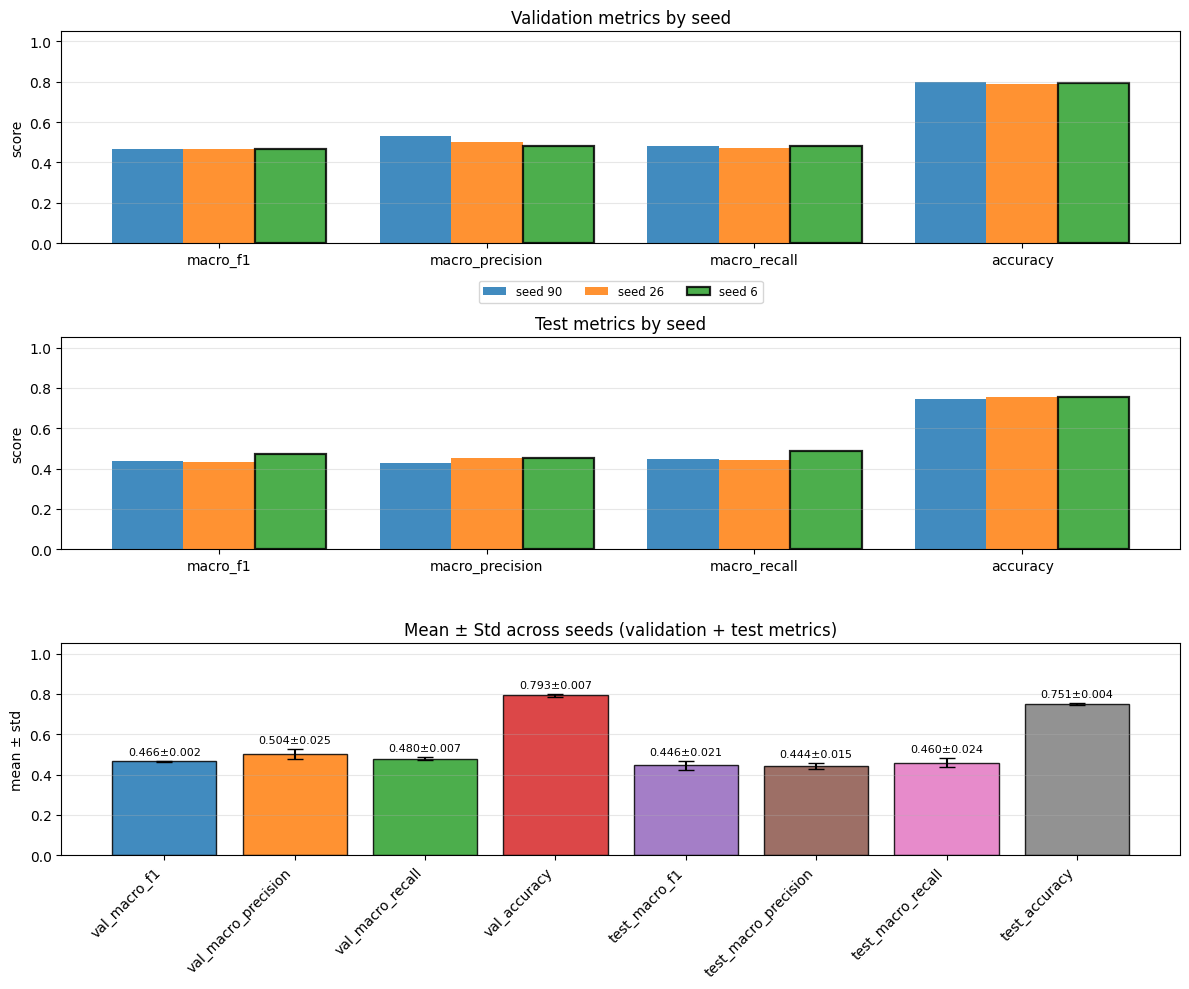

In [ ]:
agg_cleaned, best_run_cleaned, best_seed_cleaned = print_outputs_and_hystograms(df_out_cleaned, name_model="Cleaned")

as expected, the results with pre-cleaned tweets are worse than those with raw tweets. But better of the partial fine-tuning.

============================    Best model full fine-tuned     ============================


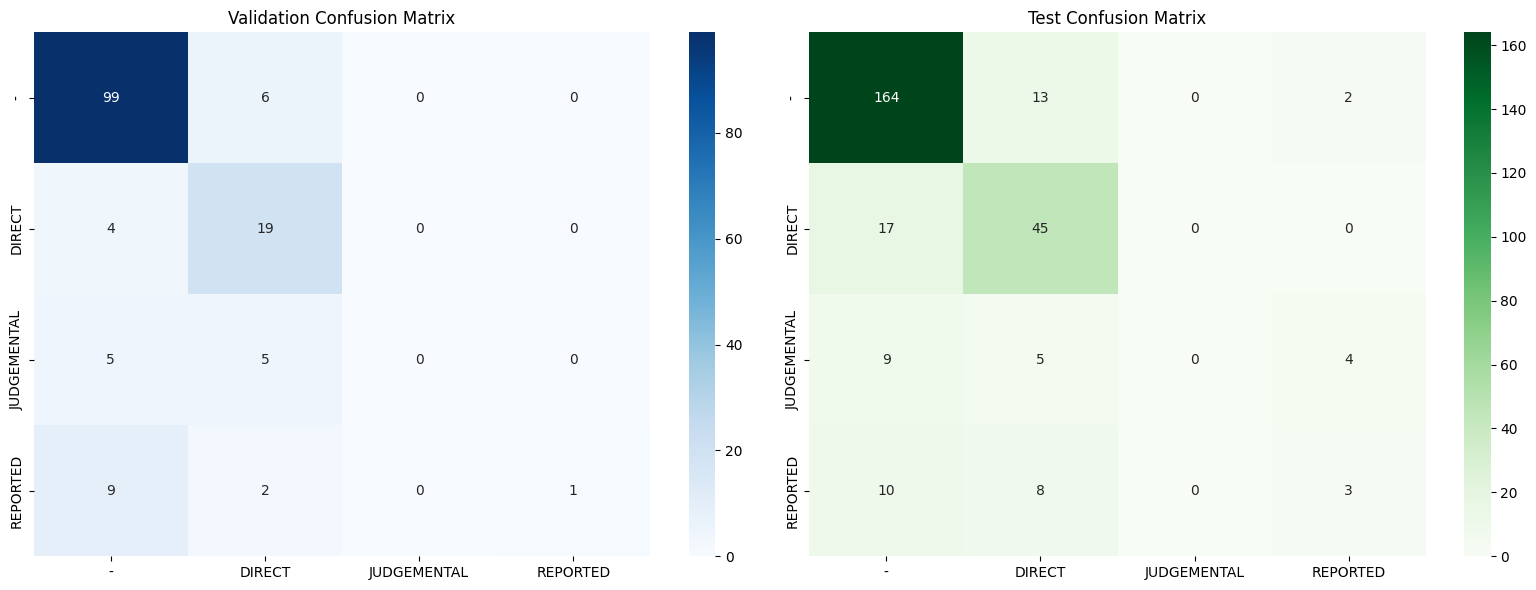

============================   Best model partial fine-tuned   ============================


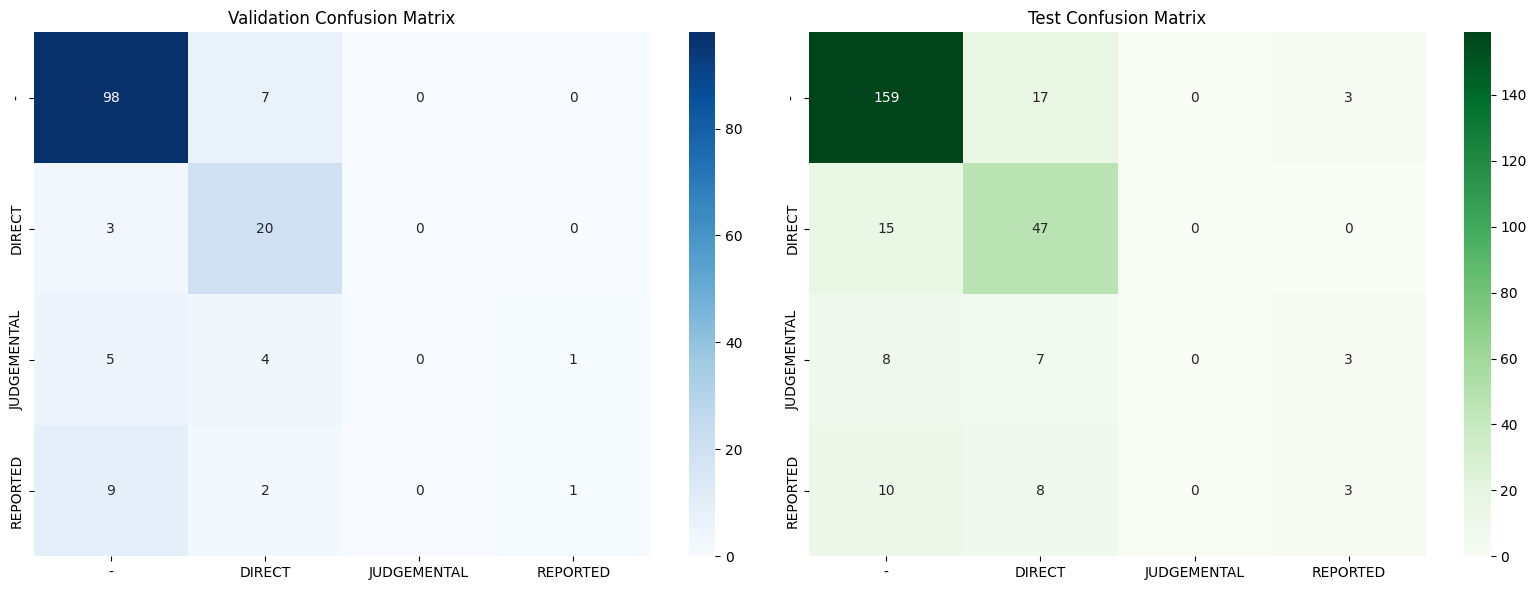

============================   Best model cleaned fine-tuned   ============================


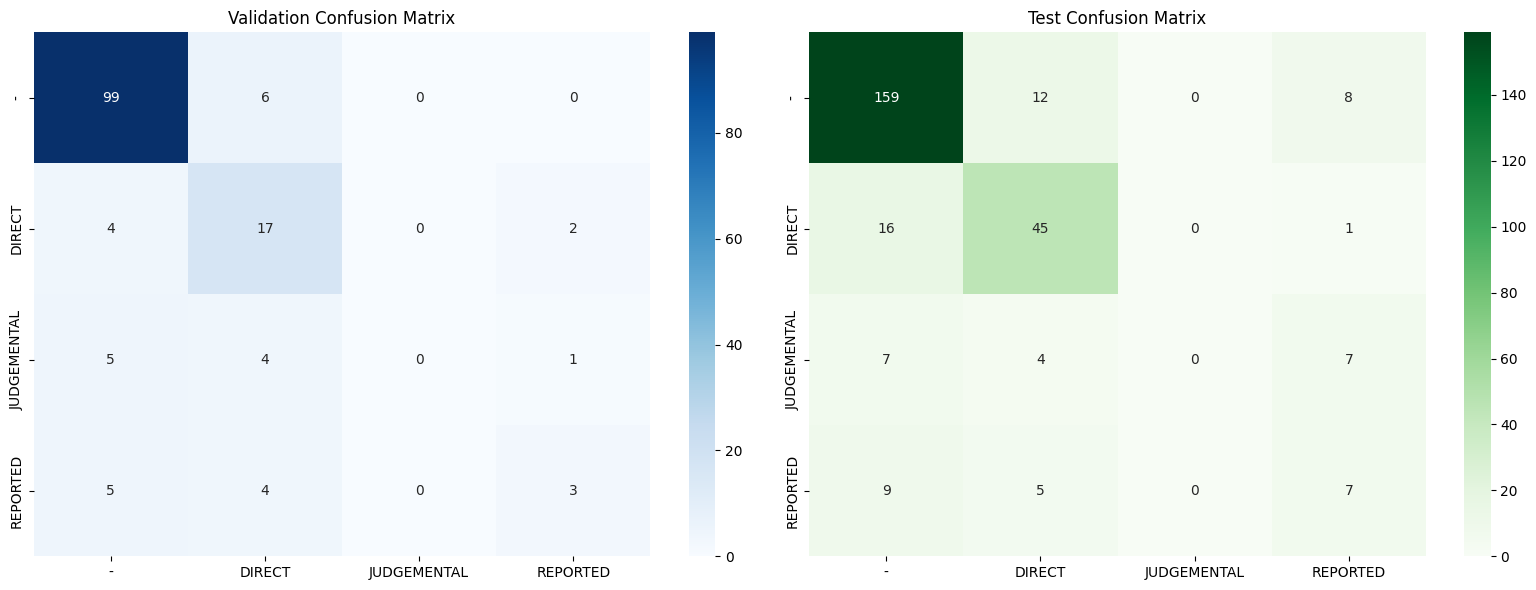

In [ ]:
print("============================    Best model full fine-tuned     ============================")
plot_confusion_matrices(best_model_dirs, best_seed, label_mapping.keys())
print("============================   Best model partial fine-tuned   ============================")
plot_confusion_matrices(best_model_dirs_partial, best_seed_partial, label_mapping.keys())
print("============================   Best model cleaned fine-tuned   ============================")
plot_confusion_matrices(best_model_dirs_cleaned, best_seed_cleaned, label_mapping.keys())

# [Task 8 - 0.5 points] Report

Wrap up your experiment in a short report (up to 2 pages).

### Instructions

* Use the NLP course report template.
* Summarize each task in the report following the provided template.

### Recommendations

The report is **not a copy-paste** of graphs, tables, and command outputs.

* Summarize classification performance in Table format.
* **Do not** report command outputs or screenshots.
* Report learning curves in Figure format.
* The error analysis section should summarize your findings.


# Submission

* **Submit** your report in PDF format.
* **Submit** your python notebook.
* Make sure your notebook is **well organized**, with no temporary code, commented sections, tests, etc...
* You can upload **model weights** in a cloud repository and report the link in the report.

## Bonus Points
Bonus points are arbitrarily assigned based on significant contributions such as:
- Outstanding error analysis
- Masterclass code organization
- Suitable extensions

**Note**: bonus points are only assigned if all task points are attributed (i.e., 6/6).

**Possible Suggestions for Bonus Points:**
- **Try other preprocessing strategies**: e.g., but not limited to, explore techniques tailored specifically for tweets or  methods that are common in social media text.
- **Experiment with other custom architectures or models from HuggingFace**
- **Explore Spanish tweets**: e.g., but not limited to, leverage multilingual models to process Spanish tweets and assess their performance compared to monolingual models.

# FAQ

Please check this frequently asked questions before contacting us

### Trainable Embeddings

You are **free** to define a trainable or non-trainable Embedding layer to load the GloVe embeddings.

### Model architecture

You **should not** change the architecture of a model (i.e., its layers).

However, you are **free** to play with their hyper-parameters.


### Neural Libraries

You are **free** to use any library of your choice to implement the networks (e.g., Keras, Tensorflow, PyTorch, JAX, etc...)

### Robust Evaluation

Each model is trained with at least 3 random seeds.

Task 5 requires you to compute the average performance over the 3 seeds and its corresponding standard deviation.

### Expected Results

Task 2 leaderboard reports around 40-50 F1-score.
However, note that they perform a hierarchical classification.

That said, results around 30-40 F1-score are **expected** given the task's complexity.

### Model Selection for Analysis

To carry out the error analysis you are **free** to either

* Pick examples or perform comparisons with an individual seed run model (e.g., Baseline seed 1337)
* Perform ensembling via, for instance, majority voting to obtain a single model.

### Error Analysis

Some topics for discussion include:
   * Precision/Recall curves.
   * Confusion matrices.
   * Specific misclassified samples.


# The End

Feel free to reach out for questions/doubts!